In [27]:
from pathlib import Path
import pickle
import numpy as np
import gvar as gv

import matplotlib.pyplot as plt
%matplotlib inline

from measurements import *
from flowing import flowtime_to_radius

In [2]:
ns = 64
nt = 16

flowtimes = np.array([ 0.02572923590301565, 0.05303278154520656, 0.08103495224784385, 0.110208782326772, 0.141058391298962, 0.1736893835495303,
                       0.2086835114617738, 0.2454549361253429, 0.2838117228448263, 0.3249152519239425, 0.3705101434001126, 0.4179449298122797,
                       0.4696233239687699, 0.5279559816139976, 0.5890993819917063, 0.6570215111572449, 0.734680305158274, 0.8257738792221512,
                       0.9353328035912798, 1.06959076807306, 1.233820281085228, 1.435936459574629 ], dtype=float)#, 1.68034447439404, 1.972161672512587 ]

local_tol = 3.00e-04    # flowtimes based on this (not used here)
flow_type = 'zeuthen'   # just for information, prabably not needed

In [6]:
data_path = Path.cwd() / 'data'

flowmeas_config : list[FlowMeasurements] = pickle.load((data_path / 'data0a.pkl').open('rb'))

ense_all = np.load(data_path / 'data0.npy')
print(ense_all.shape)

print('number of configs =', len(flowmeas_config))

(3055, 22, 9, 1914)
number of configs = 3055


In [9]:
# all improved topological charges (first index is config, second is flowtime)

n_configs   = len(flowmeas_config)
n_flowtimes = len(flowtimes)

icharge_config_flow = np.array(
    [ [meas.icharge for meas in flowmeas]
      for flowmeas in flowmeas_config ],
    dtype=float
)
print(icharge_config_flow.shape, icharge_config_flow.dtype)

(3055, 22) float64


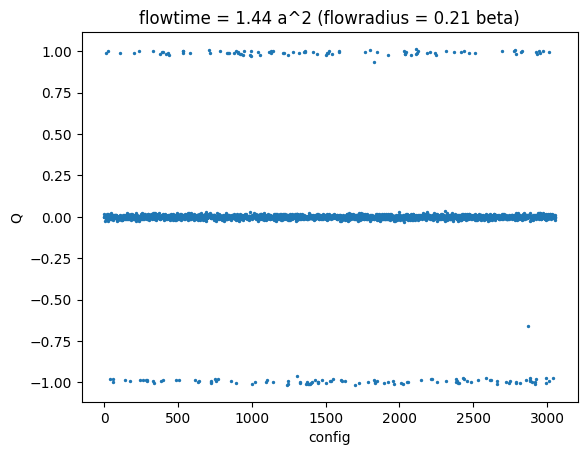

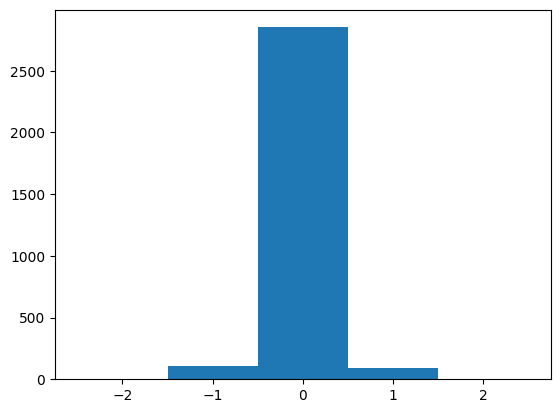

In [ ]:
# plotting topological charge for each configuration

iflow = -1

plt.scatter(
    x = range(n_configs),
    y = icharge_config_flow[:, iflow],
    s = 2,
    # label = f't = {flowtimes[iflow]:.2f}'
)
plt.xlabel('config')
plt.ylabel('Q')
# plt.legend()
plt.title(f'flowtime = {flowtimes[iflow]:.2f} a^2 (flowradius = {flowtime_to_radius(flowtimes[iflow], nt):.2f} beta)')
plt.show()
plt.close()


plt.hist(
    x = icharge_config_flow[:, iflow],
    bins = (-2.5, -1.5, -0.5, 0.5, 1.5, 2.5)
)
plt.show()

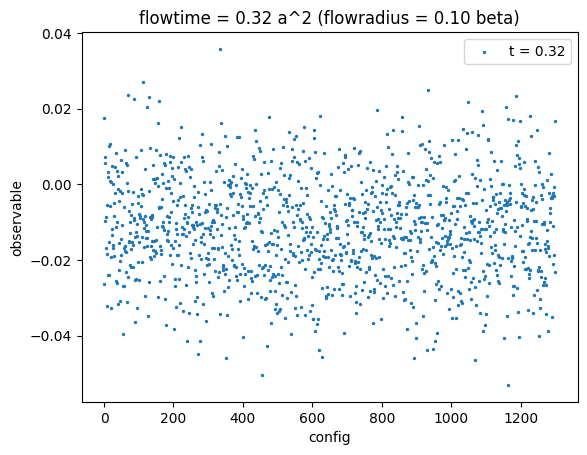

In [54]:
# thermalization

iflow = 9
config_max = 1300

obs = ense_all[:, iflow, 5, 2]

plt.scatter(
    x = range(config_max),
    y = obs[:config_max],
    s = 2,
    label = f't = {flowtimes[iflow]:.2f}'
)
plt.xlabel('config')
plt.ylabel('observable')
plt.legend()
plt.title(f'flowtime = {flowtimes[iflow]:.2f} a^2 (flowradius = {flowtime_to_radius(flowtimes[iflow], nt):.2f} beta)')
plt.show()

/tmp/ipykernel_2195056/2056675738.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


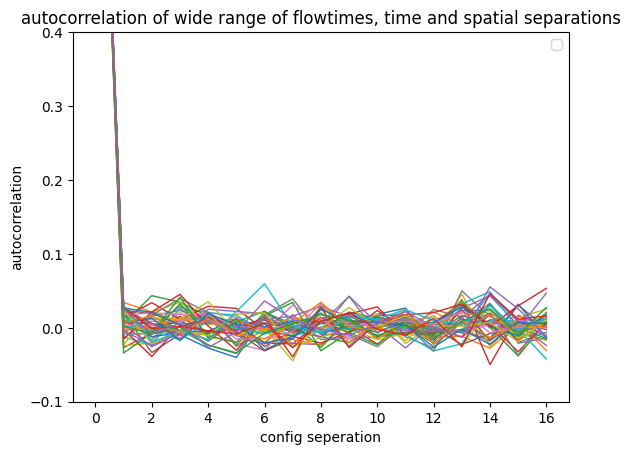

In [56]:
# check autocorrelation

skip = 55

taus   = [4,6,8]
iflows = [11, 16, 21]
irs    = [0, 5, 15, 30, 45]

for iflow in iflows:
    for tau in taus:
        for ir in irs:
            autocorrs = gv.dataset.autocorr(ense_all[skip:, iflow, tau, ir])
            plt.plot(
                autocorrs[:17],
                lw = 1,
                # label = f'ifl={ifl}'
            )
            plt.legend()

plt.ylim(-0.1, 0.4)
plt.xlabel('config seperation')
plt.ylabel('autocorrelation')
plt.title('autocorrelation of wide range of flowtimes, time and spatial separations')
plt.show()